Célula 1 – imports básicos

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Deixa os gráficos aparecerem no notebook
%matplotlib inline

Célula 2 – carregar o CSV

In [52]:
df = pd.read_csv("resultados_sdn.csv")
df.head()


,timestamp,host_src,host_dst,latencia_ms,vazao_Mbps
0,2025-11-30T15:38:50,h1,h6,NaN,NaN
1,2025-11-30T16:04:18,h1,h6,NaN,NaN
2,2025-11-30T16:16:44,h1,h6,NaN,NaN
3,2025-11-30T16:31:02,h1,h6,NaN,NaN
4,2025-11-30T16:51:48,h1,h6,NaN,NaN


Célula 3 – limpar e converter para número

In [53]:
df_clean = df.copy()

# Converte vazio -> NaN e depois para float
df_clean['latencia_ms'] = pd.to_numeric(df_clean['latencia_ms'], errors='coerce')
df_clean['vazao_Mbps']  = pd.to_numeric(df_clean['vazao_Mbps'],  errors='coerce')

# Remove linhas onde não teve latência ou vazão medida
df_clean = df_clean.dropna(subset=['latencia_ms', 'vazao_Mbps'])

df_clean = df_clean.reset_index(drop=True)
df_clean['execucao'] = df_clean.index + 1

df_clean


,timestamp,host_src,host_dst,latencia_ms,vazao_Mbps,execucao
0,2025-11-30T17:41:59,h1,h6,0.038,18907.0009,1


Célula 4 – gráfico da latência

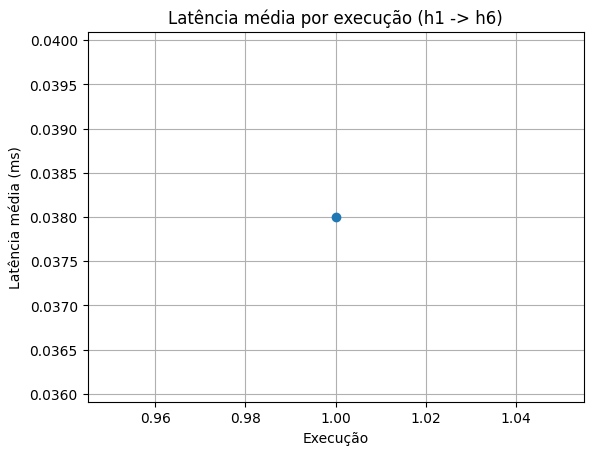

In [54]:
plt.figure()
plt.plot(df_clean['execucao'], df_clean['latencia_ms'], marker='o') 
plt.xlabel('Execução')
plt.ylabel('Latência média (ms)') 
plt.title('Latência média por execução (h1 -> h6)')
plt.grid(True)
plt.show()


Célula 5 – gráfico da vazão

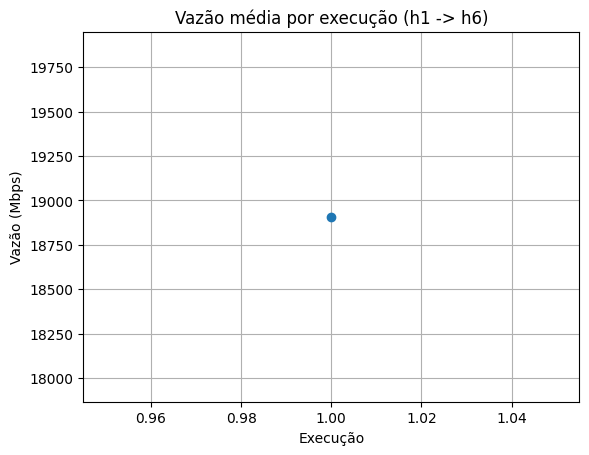

In [55]:
plt.figure()
plt.plot(df_clean['execucao'], df_clean['vazao_Mbps'], marker='o')
plt.xlabel('Execução')
plt.ylabel('Vazão (Mbps)')
plt.title('Vazão média por execução (h1 -> h6)')
plt.grid(True)
plt.show()
